<a href="https://colab.research.google.com/github/erskordi/ME561/blob/main/ML4A_3_5_PP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sample code

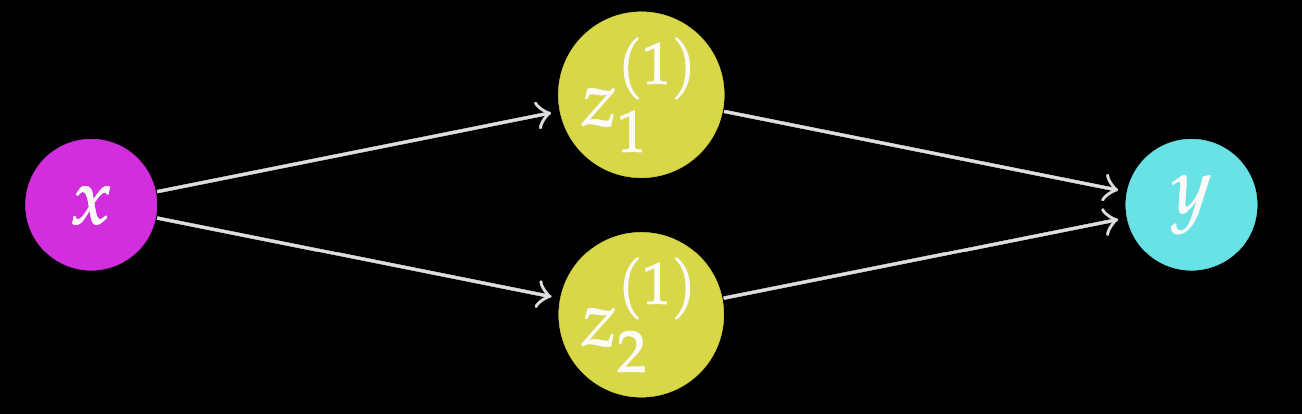

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(19)

class yourfirstNN:
    def __init__(self):
        self.z1 = None
        self.W1 = np.random.randn(1, 2)
        self.W2 = np.random.randn(2, 1)
        self.b1 = np.random.randn(2)
        self.b2 = np.random.randn(1)
        self.learning_rate = 0.01
        self.loss_history = []

    def ReLU(self, x):
        return np.maximum(0, x)

    def gReLU(self, x):
        return np.where(x > 0, 1, 0)

    def forward(self, x):
        self.z1 = self.ReLU(x @ self.W1 + self.b1)
        y_hat = self.z1 @ self.W2 + self.b2
        return y_hat

    def train(self, X, Y, n_epochs):
        X = X.reshape(-1, 1)
        for epoch in range(n_epochs):
            total_loss = 0.0

            gW1 = np.zeros_like(self.W1)
            gW2 = np.zeros_like(self.W2)
            gb1 = np.zeros_like(self.b1)
            gb2 = np.zeros_like(self.b2)

            for x, y_true in zip(X, Y):
                x = x.reshape(1, -1)
                y_true = np.array([y_true]).reshape(-1, 1)

                # Forward propagation
                y_hat = self.forward(x)
                loss = (y_true - y_hat) ** 2
                total_loss += loss.mean()

                # Backward propagation
                dL_dy_hat = -2 * (y_true - y_hat)

                gW2 += self.z1.T @ dL_dy_hat
                gb2 += dL_dy_hat.sum(axis=0)

                dz_hidden = dL_dy_hat @ self.W2.T * self.gReLU(self.z1)

                gW1 += x.T @ dz_hidden
                gb1 += dz_hidden.sum(axis=0)

            n_samples = X.shape[0]
            self.W1 -= self.learning_rate * gW1 / n_samples
            self.b1 -= self.learning_rate * gb1 / n_samples
            self.W2 -= self.learning_rate * gW2 / n_samples
            self.b2 -= self.learning_rate * gb2 / n_samples

            self.loss_history.append(total_loss / n_samples)

    def predict(self, X):
        X = np.array(X).reshape(-1, 1)
        return self.forward(X).flatten()

In [11]:
np.random.seed(19)

In [12]:
# Data
X = np.sort(np.random.randn(100))
Y = np.abs(X) + 0.1 * np.random.randn(100)

nn = yourfirstNN()
nn.train(X, Y, n_epochs=1000)

Y_hat = nn.predict(X)

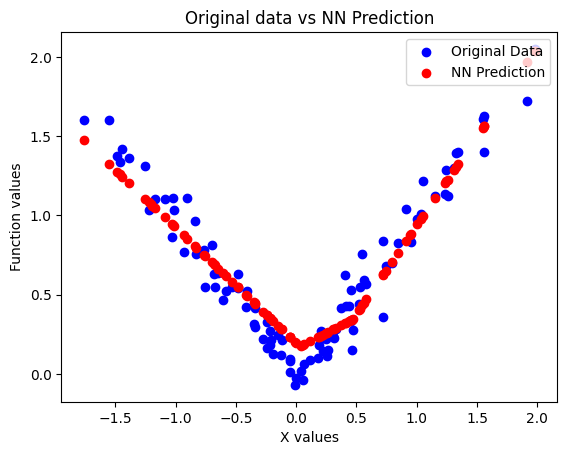

In [13]:
plt.scatter(X, Y, label="Original Data", color='blue')
plt.scatter(X, Y_hat, label="NN Prediction", color='red')
plt.xlabel("X values")
plt.ylabel("Function values")
plt.title("Original data vs NN Prediction")
plt.legend(loc='upper right')
plt.show()

# Build NN with pytorch with few lines

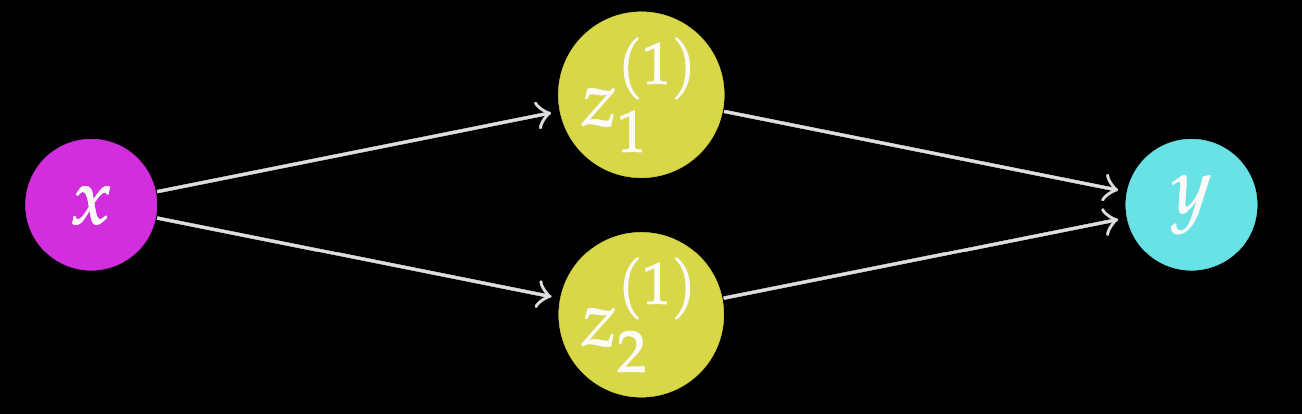

In [14]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(19)

model = nn.Sequential(
    nn.Linear(1, 2),
    nn.ReLU(),        # activation function
    nn.Linear(2, 1)
)

In [15]:
print(model)

Sequential(
  (0): Linear(in_features=1, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=1, bias=True)
)


In [16]:
def training_loop(n_epochs, optimizer, model, loss_fn, data, labels):
    for epoch in range(1, n_epochs + 1):
        preds = model(data)
        loss_train = loss_fn(preds, labels)

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f}")

In [17]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

training_loop(
    n_epochs = 5000,
    optimizer = optimizer,
    model = model,
    loss_fn = nn.MSELoss(),
    data=torch.tensor(X).float().reshape(-1, 1),
    labels=torch.tensor(Y).float().reshape(-1, 1)
)

Epoch 1, Training loss 2.3966
Epoch 1000, Training loss 0.0418
Epoch 2000, Training loss 0.0103
Epoch 3000, Training loss 0.0102
Epoch 4000, Training loss 0.0102
Epoch 5000, Training loss 0.0102


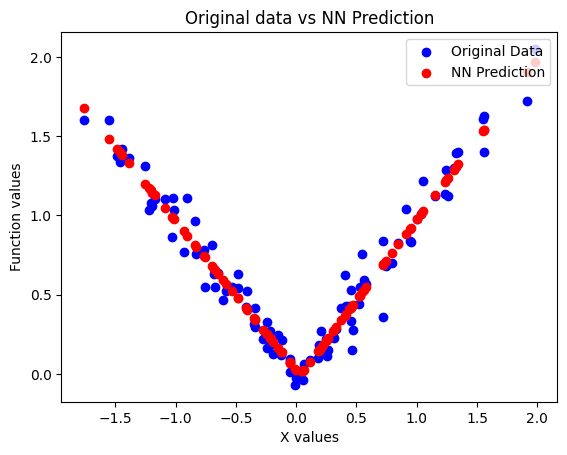

In [18]:
Y_hat = model(torch.tensor(X).float().reshape(-1, 1)).detach().numpy()

plt.scatter(X, Y, label="Original Data", color='blue')
plt.scatter(X, Y_hat, label="NN Prediction", color='red')
plt.xlabel("X values")
plt.ylabel("Function values")
plt.title("Original data vs NN Prediction")
plt.legend(loc='upper right')
plt.show()